# ER-2 planned vs. flown — Green Card / KML / IWG1 comparison

Three-way comparison between a NASA ER-2 mission's *planned* product (KML route + Green Card mission data card), the *as-flown* IWG1 in-situ recording, and HyPlan's *modeled* trajectory built from the calibrated [`NASA_ER2()`](../../hyplan/aircraft/_models.py).

This notebook focuses on the **NM17 B** pair (planned 04/19, flown 2026-04-19); the §12 multi-pair scan also runs **CO07v4**, **CO06**, **NM10Bv3**, and **NM09** through the same pipeline. See [PAIRS.md](PAIRS.md) for the full pair table.

The calibrated `NASA_ER2()` model used here is fit to **199 IWG1 sorties** in `data/er2/` (in-house delivery + public NASA ASP archive crawl) (post-cleanup: time-gap-based sortie split, ground-taxi trim, removal of test/abort/missing-climb fragments). The §13 noise floor section quantifies the irreducible per-sortie spread across that calibration set.

Pipeline:

1. `load_planned_sortie(kml, gc)` → ordered planned-event table + header.
2. `load_iwg1(path)` + `trim_ground_taxi` → as-flown trace.
3. Mission-level summary (planned vs. flown total / TOC / on-station / descent).
4. Fix-by-fix comparison at numbered waypoints.
5. Build a HyPlan flight plan with a constant cruise-mean wind.
6. Re-plan with an altitude-resolved `IWG1TraceWindField`.
7. Decompose the residual by phase and by `/L` endpoint.
8. Top-of-climb / top-of-descent location and timing.
9. Ground-track comparison (planned / flown / HyPlan).
10. Altitude-profile comparison.
11. Pre-/post-survey staging waypoints.
12. Multi-pair scan (NM17 B, CO07v4, CO06, NM10Bv3, NM09).
13. Calibration noise floor (138-sortie spread).
14. Findings.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from hyplan import initialize_data
from hyplan.aircraft import (
    load_iwg1, trim_ground_taxi, load_planned_sortie,
)

DATA_DIR = Path("../../../data/er2").resolve()

# NM17 B pair (see PAIRS.md). Swap to other pairs once their parsers land.
PLANNED_NAME = "NM17 B"
PLANNED_KML  = DATA_DIR / "NM17 B KML.kml"
PLANNED_GC   = DATA_DIR / "NM17 B ER2 Green Card1.xlsx"
FLOWN_IWG1   = DATA_DIR / "n806_2026-04-19.txt"
MIN_CRUISE_ALT_FT = 50_000

initialize_data(countries=["US"])
print(f"pair: {PLANNED_NAME}")
print(f"  KML : {PLANNED_KML.name}")
print(f"  GC  : {PLANNED_GC.name}")
print(f"  IWG1: {FLOWN_IWG1.name}")

pair: NM17 B
  KML : NM17 B KML.kml
  GC  : NM17 B ER2 Green Card1.xlsx
  IWG1: n806_2026-04-19.txt


## 1. Load the planned sortie

Header carries the mission identity, schedule, and fuel state. The waypoint table has one row per planned event — numbered waypoints plus inline `.level off` / `.delay` / `.descent pt` sub-rows.

In [2]:
planned = load_planned_sortie(PLANNED_KML, PLANNED_GC)
for k, v in planned.header.items():
    print(f"  {k:24s} {v}")
print()
print(f"events: {len(planned.waypoints):d}  (counts by kind: {dict(planned.waypoints['kind'].value_counts())})")
planned.waypoints[[
    "order", "wp_num", "fix_name", "kind", "lat_deg", "lon_deg",
    "altitude_ft", "leg_time_min", "cumulative_time_min", "tas_kt",
]].head(10)

  aircraft_id              NASA806
  mission_name             GEMX
  sched_takeoff_z          15:30:00
  takeoff_time_z           15:30:00
  land_time_z              22:03:35
  sched_duration_hours     6.559722222222222
  fuel_load_lb             1853
  fuel_used_lb             1332

events: 44  (counts by kind: {'waypoint': np.int64(38), 'level_off': np.int64(2), 'delay': np.int64(2), 'descent_pt': np.int64(2)})


,order,wp_num,fix_name,kind,lat_deg,lon_deg,altitude_ft,leg_time_min,cumulative_time_min,tas_kt
0,1,1.0,KCOS/A,waypoint,38.805833,-104.700833,6187.0,0.0,0.0,NaN
1,2,2.0,BRK/E,waypoint,38.944500,-104.633500,23990.0,3.4,3.4,NaN
2,3,NaN,.level off,level_off,38.924500,-104.634833,26000.0,0.4,3.8,NaN
3,4,3.0,PUB/R253012,waypoint,38.262667,-104.680333,26000.0,7.0,10.8,328.0
4,5,4.0,PUB/R206014,waypoint,38.093333,-104.600167,35578.0,2.5,13.3,NaN
5,6,NaN,.delay,delay,38.093333,-104.600167,61186.0,25.0,38.3,NaN
6,7,NaN,.level off,level_off,37.148833,-104.174333,65000.0,9.0,47.3,NaN
7,8,5.0,TBE/E245028,waypoint,37.148833,-104.174333,65000.0,0.1,47.4,683.0
8,9,6.0,M251N/L,waypoint,37.085167,-104.168333,65000.0,0.6,48.0,396.0
9,10,7.0,M251S/L,waypoint,34.463833,-104.168333,65000.0,23.9,71.9,395.0


## 2. Load the matched as-flown sortie

Same `load_iwg1` + `trim_ground_taxi` pipeline used in [sortie_replay.ipynb](sortie_replay.ipynb). The inline `label_phases` is the simple VS-threshold classifier from `iwg1_calibration.ipynb`.

In [3]:
def label_phases(df, climb_fpm=300.0, descent_fpm=-300.0, min_seconds=60.0):
    df = df.copy()
    df["phase"] = "cruise"
    df.loc[df["vertical_rate"] >= climb_fpm, "phase"] = "climb"
    df.loc[df["vertical_rate"] <= descent_fpm, "phase"] = "descent"
    t = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds().to_numpy()
    phases = df["phase"].to_numpy()
    if len(phases) < 2: return df
    runs, start = [], 0
    for i in range(1, len(phases) + 1):
        if i == len(phases) or phases[i] != phases[start]:
            runs.append((start, i, phases[start])); start = i
    out = phases.copy()
    for s, e, _ in runs:
        if e - s == 0: continue
        duration = (t[e - 1] - t[s]) if e - 1 > s else 0
        if duration < min_seconds:
            prev_p = out[s - 1] if s > 0 else None
            next_p = out[e] if e < len(out) else None
            replacement = prev_p if prev_p is not None else next_p
            if replacement is not None:
                out[s:e] = replacement
    df["phase"] = out
    return df

raw = load_iwg1(FLOWN_IWG1)
actual = trim_ground_taxi(raw)
actual = label_phases(actual)
actual_takeoff = actual["timestamp"].iloc[0]
actual_landing = actual["timestamp"].iloc[-1]
actual_total_min = (actual_landing - actual_takeoff).total_seconds() / 60.0
actual_max_alt_ft = float(actual["altitude"].max())
print(f"sortie date         : {actual_takeoff.strftime('%Y-%m-%d')}")
print(f"airborne fixes      : {len(actual):>5d}")
print(f"actual takeoff (Z)  : {actual_takeoff.strftime('%H:%M:%S')}")
print(f"actual landing (Z)  : {actual_landing.strftime('%H:%M:%S')}")
print(f"total duration      : {actual_total_min:.1f} min")
print(f"max altitude        : {actual_max_alt_ft:.0f} ft")

sortie date         : 2026-04-19
airborne fixes      :  4527
actual takeoff (Z)  : 15:26:07
actual landing (Z)  : 21:43:22
total duration      : 377.2 min
max altitude        : 65982 ft


## 3. Mission-level summary

Planned values come from the Green Card (cumulative time at the relevant boundary events). Flown values come from the IWG1 trace using the same boundary definitions used by [sortie_replay.ipynb](sortie_replay.ipynb): TOC = first fix at ≥ `MIN_CRUISE_ALT_FT`, TOD = last such fix, on-station = cruise-phase fixes ≥ `MIN_CRUISE_ALT_FT`.

In [4]:
df = planned.waypoints

# Planned TOC: linear interpolation across the planned events on
# (cumulative_time_min, altitude_ft) to find the time when altitude
# first reaches MIN_CRUISE_ALT_FT.  ER-2 plans climb in steps with
# .level off events, so the trace is monotonic during the climb phase.
alt = df["altitude_ft"].to_numpy()
ct = df["cumulative_time_min"].to_numpy()
above = alt >= MIN_CRUISE_ALT_FT
first_high = int(np.argmax(above)) if above.any() else None
last_high  = int(len(above) - 1 - np.argmax(above[::-1])) if above.any() else None
if first_high is not None and first_high > 0:
    a0, a1 = alt[first_high - 1], alt[first_high]
    t0, t1 = ct[first_high - 1], ct[first_high]
    frac = (MIN_CRUISE_ALT_FT - a0) / (a1 - a0) if a1 != a0 else 0.0
    planned_toc_min = t0 + frac * (t1 - t0)
else:
    planned_toc_min = float("nan")
if last_high is not None and last_high < len(alt) - 1:
    a0, a1 = alt[last_high], alt[last_high + 1]
    t0, t1 = ct[last_high], ct[last_high + 1]
    frac = (MIN_CRUISE_ALT_FT - a0) / (a1 - a0) if a1 != a0 else 0.0
    planned_tod_min = t0 + frac * (t1 - t0)
else:
    planned_tod_min = float("nan")
planned_total_min = float(df["cumulative_time_min"].iloc[-1])
planned_on_station_min = planned_tod_min - planned_toc_min
planned_descent_min = planned_total_min - planned_tod_min

# Flown side
above_a = (actual["altitude"] >= MIN_CRUISE_ALT_FT)
in_high = above_a & (actual["phase"] == "cruise")
fhi = above_a.idxmax() if above_a.any() else None
lhi = above_a[::-1].idxmax() if above_a.any() else None
actual_toc_min = ((actual.loc[fhi, "timestamp"] - actual_takeoff).total_seconds() / 60.0
                  if fhi is not None else float("nan"))
actual_tod_min = ((actual.loc[lhi, "timestamp"] - actual_takeoff).total_seconds() / 60.0
                  if lhi is not None else float("nan"))
actual_on_station_min = actual_tod_min - actual_toc_min
actual_descent_min = actual_total_min - actual_tod_min

summary = pd.DataFrame([
    {"metric": "total_duration_min",       "planned": round(planned_total_min, 1),       "flown": round(actual_total_min, 1)},
    {"metric": "time_to_cruise_min",       "planned": round(planned_toc_min, 1),         "flown": round(actual_toc_min, 1)},
    {"metric": "time_on_station_min",      "planned": round(planned_on_station_min, 1),  "flown": round(actual_on_station_min, 1)},
    {"metric": "descent_min",              "planned": round(planned_descent_min, 1),     "flown": round(actual_descent_min, 1)},
])
summary["delta_min"] = (summary["flown"] - summary["planned"]).round(1)
summary["pct"] = (summary["delta_min"] / summary["planned"] * 100).round(1)
summary.set_index("metric")

,planned,flown,delta_min,pct
metric,,,,
total_duration_min,393.6,377.2,-16.4,-4.2
time_to_cruise_min,27.4,22.3,-5.1,-18.6
time_on_station_min,332.0,328.7,-3.3,-1.0
descent_min,34.2,26.2,-8.0,-23.4


## 4. Fix-by-fix comparison

Walk the numbered planned waypoints in order; for each, find the *next* IWG1 fix that comes within ~5 nmi of the planned lat/lon (sequential matching handles racetrack patterns where the aircraft passes over a fix multiple times). Compare planned ATA (cumulative time) vs. flown ATA at that fix; report altitude residual.

In [5]:
def _haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1r, lat2r = np.radians(lat1), np.radians(lat2)
    dlat = lat2r - lat1r
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

MATCH_RADIUS_NMI = 5.0
MATCH_RADIUS_KM = MATCH_RADIUS_NMI * 1.852

wpts = planned.waypoints[planned.waypoints["kind"] == "waypoint"].reset_index(drop=True)
actual_lat = actual["latitude"].to_numpy()
actual_lon = actual["longitude"].to_numpy()
actual_alt = actual["altitude"].to_numpy()
actual_ts = actual["timestamp"].to_numpy()

rows = []
search_start = 0
for _, w in wpts.iterrows():
    if pd.isna(w["lat_deg"]) or pd.isna(w["lon_deg"]):
        continue
    d_km = _haversine_km(
        w["lat_deg"], w["lon_deg"],
        actual_lat[search_start:], actual_lon[search_start:],
    )
    in_range = d_km <= MATCH_RADIUS_KM
    if not in_range.any():
        rows.append({
            "wp_num": int(w["wp_num"]),
            "fix_name": w["fix_name"],
            "planned_ata_min": float(w["cumulative_time_min"]),
            "flown_ata_min": float("nan"),
            "delta_min": float("nan"),
            "planned_alt_ft": float(w["altitude_ft"]),
            "flown_alt_ft": float("nan"),
            "alt_delta_ft": float("nan"),
            "closest_dist_nmi": float(np.nanmin(d_km) / 1.852) if len(d_km) else float("nan"),
        })
        continue
    # Restrict to the *first contiguous in-range run* starting from
    # search_start; that's the time the aircraft actually passed over
    # this fix on this leg.  Subsequent revisits (racetracks, returns
    # to a fix on the way home) belong to later planned waypoints.
    first_in = int(np.argmax(in_range))
    out_idx = np.where(~in_range[first_in:])[0]
    end_of_run = first_in + int(out_idx[0]) if len(out_idx) else len(in_range)
    local_idx = first_in + int(np.argmin(d_km[first_in:end_of_run]))
    abs_idx = search_start + local_idx
    flown_t = (pd.Timestamp(actual_ts[abs_idx]) - actual_takeoff).total_seconds() / 60.0
    rows.append({
        "wp_num": int(w["wp_num"]),
        "fix_name": w["fix_name"],
        "planned_ata_min": float(w["cumulative_time_min"]),
        "flown_ata_min": round(flown_t, 1),
        "delta_min": round(flown_t - float(w["cumulative_time_min"]), 1),
        "planned_alt_ft": float(w["altitude_ft"]),
        "flown_alt_ft": round(float(actual_alt[abs_idx])),
        "alt_delta_ft": round(float(actual_alt[abs_idx] - w["altitude_ft"])),
        "closest_dist_nmi": round(float(d_km[local_idx]) / 1.852, 2),
    })
    # Advance the search window past the end of this in-range run so
    # the next planned waypoint matches a strictly later fix.
    search_start = search_start + end_of_run

fix_table = pd.DataFrame(rows)
matched = fix_table[fix_table["flown_ata_min"].notna()]
print(f"matched {len(matched)} of {len(fix_table)} numbered waypoints within {MATCH_RADIUS_NMI} nmi")
if len(matched):
    print(f"median |delta_min|:    {matched['delta_min'].abs().median():.1f} min")
    print(f"median |alt_delta_ft|: {matched['alt_delta_ft'].abs().median():.0f} ft")
fix_table

matched 36 of 38 numbered waypoints within 5.0 nmi
median |delta_min|:    3.1 min
median |alt_delta_ft|: 396 ft


,wp_num,fix_name,planned_ata_min,flown_ata_min,delta_min,planned_alt_ft,flown_alt_ft,alt_delta_ft,closest_dist_nmi
0,1,KCOS/A,0.0,0.2,0.2,6187.0,5830.0,-357.0,0.710000
1,2,BRK/E,3.4,NaN,NaN,23990.0,NaN,NaN,6.097904
2,3,PUB/R253012,10.8,13.8,2.9,26000.0,35860.0,9860.0,4.540000
3,4,PUB/R206014,13.3,29.3,16.0,35578.0,55818.0,20240.0,2.850000
4,5,TBE/E245028,47.4,45.8,-1.6,65000.0,63515.0,-1485.0,0.350000
5,6,M251N/L,48.0,46.6,-1.4,65000.0,63580.0,-1420.0,1.480000
6,7,M251S/L,71.9,69.7,-2.2,65000.0,65458.0,458.0,0.020000
7,8,CNX/R080052,76.2,74.0,-2.2,65000.0,64855.0,-145.0,0.840000
8,9,M245S/L,78.1,76.1,-2.0,65000.0,64572.0,-428.0,0.210000
9,10,M245N/L,102.0,99.6,-2.4,65000.0,65600.0,600.0,0.180000


## 5. Build a HyPlan flight plan from the planned sortie

Convert the parsed Green Card waypoints into the inputs `compute_flight_plan` accepts:

* **Detection rule (NM17 B and other observed ER-2 products):** every flight-line endpoint carries the `/L` suffix (`M251N/L`, `T643S/L`, …). Pairs of consecutive `/L` waypoints define one `FlightLine`. The non-`/L` waypoints between them (`CNX/R080052`, `CIM/R348042`, `TBE/Exxx`, `CVS/Txxx`) are stand-ins for the planner's Dubins turns and are dropped — HyPlan generates its own.
* **Climb-out / descent-in connectors** (the named navaid hops at the head and tail, plus `.level off`, `.delay`, `.descent pt` sub-rows) are also dropped. HyPlan's `compute_flight_plan` derives those from the takeoff and return airports plus the calibrated [`NASA_ER2()`](../../hyplan/aircraft/_models.py) climb / descent profiles.
* **Departure / arrival airports** come from the first / last `/A`-suffixed waypoints (here both `KCOS`).
* **Per-line altitude:** the Green Card altitude is taken verbatim from the first endpoint of each pair (both endpoints share the same altitude on every NM17 B line).

This logic is intentionally kept in the notebook so the rule can be tweaked per pair without touching `hyplan/aircraft/`.

In [6]:
from hyplan import FlightLine, Airport, NASA_ER2, compute_flight_plan
from hyplan.units import ureg


def _line_id(name_a: str, name_b: str) -> str:
    """Longest common prefix of two `/L`-stripped fix names.

    `M251N/L` + `M251S/L` → `M251`; falls back to ``A_to_B`` when no
    prefix is shared.
    """
    a = name_a.removesuffix("/L")
    b = name_b.removesuffix("/L")
    n = 0
    while n < min(len(a), len(b)) and a[n] == b[n]:
        n += 1
    common = a[:n].rstrip("/-_")
    return common or f"{a}_to_{b}"


def _vector_mean_wind(speed_kt, direction_deg):
    """Vector mean of a wind series.

    Inputs are met-convention "from" (deg true) and knots. Returns
    ``(mean_speed_kt, mean_direction_deg)`` in the same convention,
    handling 0/360 wrap correctly.
    """
    s = speed_kt.dropna()
    d = direction_deg.loc[s.index].dropna()
    common = s.index.intersection(d.index)
    s, d = s.loc[common], d.loc[common]
    u = -s * np.sin(np.radians(d))   # eastward component
    v = -s * np.cos(np.radians(d))   # northward component
    um, vm = u.mean(), v.mean()
    mean_speed = float(np.hypot(um, vm))
    mean_dir = float(np.degrees(np.arctan2(-um, -vm)) % 360.0)
    return mean_speed, mean_dir


# 1. Extract the /L pairs as FlightLines.
endpoints = (
    planned.waypoints[planned.waypoints["fix_name"].str.endswith("/L")]
    .reset_index(drop=True)
)
if len(endpoints) % 2 != 0:
    raise ValueError(
        f"odd number of /L endpoints ({len(endpoints)}) — manual inspection needed"
    )

flight_lines = []
for i in range(0, len(endpoints), 2):
    a = endpoints.iloc[i]
    b = endpoints.iloc[i + 1]
    if a["altitude_ft"] != b["altitude_ft"]:
        # Per-line altitude differs between endpoints — surfaces step-cruise
        # planning on a single line.  Take the start-endpoint altitude.
        print(f"  warning: altitude mismatch on line {a['fix_name']}↔{b['fix_name']} "
              f"({a['altitude_ft']}→{b['altitude_ft']} ft); using start altitude")
    flight_lines.append(FlightLine.from_endpoints(
        lat1=float(a["lat_deg"]), lon1=float(a["lon_deg"]),
        lat2=float(b["lat_deg"]), lon2=float(b["lon_deg"]),
        altitude_msl=ureg.Quantity(float(a["altitude_ft"]), "feet"),
        site_name=_line_id(a["fix_name"], b["fix_name"]),
    ))

# 2. Departure / arrival airports (first / last /A waypoint).
airport_rows = planned.waypoints[planned.waypoints["fix_name"].str.endswith("/A")]
dep_icao = airport_rows.iloc[0]["fix_name"].removesuffix("/A")
arr_icao = airport_rows.iloc[-1]["fix_name"].removesuffix("/A")
departure = Airport(dep_icao)
arrival = Airport(arr_icao)

# 3. Constant wind field — cruise-mean (≥ MIN_CRUISE_ALT_FT, level flight)
# from the matched IWG1 trace.  This is the closest single-vector
# approximation of the winds the aircraft actually flew through.
cruise_mask = (
    (actual["altitude"] >= MIN_CRUISE_ALT_FT)
    & (actual["vertical_rate"].between(-300, 300))
)
mean_wind_kt, mean_wind_dir = _vector_mean_wind(
    actual.loc[cruise_mask, "wind_speed_kt"],
    actual.loc[cruise_mask, "wind_direction_deg"],
)
print(f"constant wind field (cruise mean from IWG1)")
print(f"  speed     : {mean_wind_kt:.1f} kt")
print(f"  direction : {mean_wind_dir:.0f}° (from)")
print()

# 4. Build the HyPlan plan.  start_offset / end_offset are 0 so modeled
# racetrack turns sit at the planned line endpoints (the default 5 nmi
# pre-extension would otherwise stretch each turn loop).  Turn radius
# now comes from `bank_by_phase` (cruise=20° for NASA_ER2 from IWG1
# calibration; see hyplan/aircraft/_models.py) — no per-aircraft
# override needed.
aircraft = NASA_ER2()

hyplan_plan_stillair = compute_flight_plan(
    aircraft=aircraft, flight_sequence=flight_lines,
    takeoff_airport=departure, return_airport=arrival,
    start_offset=0, end_offset=0,
)
hyplan_plan = compute_flight_plan(
    aircraft=aircraft, flight_sequence=flight_lines,
    takeoff_airport=departure, return_airport=arrival,
    start_offset=0, end_offset=0,
    wind_speed=mean_wind_kt * ureg.knot,
    wind_direction=mean_wind_dir,
)

bp = aircraft.turn_model.bank_by_phase
print(f"departure / arrival     : {dep_icao} / {arr_icao}")
print(f"flight lines            : {len(flight_lines)}")
print(f"bank_by_phase           : climb={bp.climb_deg}°  cruise={bp.cruise_deg}°  "
      f"descent={bp.descent_deg}°  approach={bp.approach_deg}°")
print(f"plan segments           : {len(hyplan_plan)}")
print(f"hyplan still-air total  : {hyplan_plan_stillair['time_to_segment'].sum():.1f} min")
print(f"hyplan wind-corrected   : {hyplan_plan['time_to_segment'].sum():.1f} min")
print(f"flown total             : {actual_total_min:.1f} min")
print(f"planned total           : {planned_total_min:.1f} min")
print()
fl_summary = pd.DataFrame([
    {
        "site": fl.site_name,
        "start": f"{fl.waypoint1.latitude:.3f},{fl.waypoint1.longitude:.3f}",
        "end":   f"{fl.waypoint2.latitude:.3f},{fl.waypoint2.longitude:.3f}",
        "length_nmi": fl.length.m_as(ureg.nautical_mile),
        "altitude_ft": fl.altitude_msl.m_as(ureg.foot),
    }
    for fl in flight_lines
])
fl_summary["length_nmi"] = fl_summary["length_nmi"].round(1)
fl_summary["altitude_ft"] = fl_summary["altitude_ft"].round().astype(int)
fl_summary

constant wind field (cruise mean from IWG1)
  speed     : 25.5 kt
  direction : 271° (from)



departure / arrival     : KCOS / KCOS
flight lines            : 10
bank_by_phase           : climb=11.0°  cruise=20.0°  descent=16.0°  approach=9.0°
plan segments           : 25
hyplan still-air total  : 365.9 min
hyplan wind-corrected   : 372.0 min
flown total             : 377.2 min
planned total           : 393.6 min



,site,start,end,length_nmi,altitude_ft
0,M251,"37.085,-104.168","34.464,-104.168",157.0,65000
1,M245,"34.464,-104.760","37.085,-104.760",157.0,65000
2,M246,"37.085,-104.660","34.464,-104.660",157.0,65000
3,M247,"34.464,-104.561","37.085,-104.561",157.0,65000
4,M248,"37.085,-104.462","34.464,-104.462",157.0,65000
5,M249,"34.464,-104.365","37.085,-104.365",157.0,65000
6,M250,"37.085,-104.267","34.464,-104.267",157.0,65000
7,M252,"34.464,-104.069","37.085,-104.069",157.0,65000
8,M253,"37.085,-103.970","34.464,-103.970",157.0,65000
9,T643,"34.468,-104.559","37.311,-103.429",179.0,65000


## 6. Altitude-resolved wind from the IWG1 trace itself

The constant-wind plan in §5 applies the same 26 kt @ 272° to every segment, including the takeoff climb-out at 6,000 ft and the approach at 9,000 ft where surface winds are usually a fraction of FL650 jetstream-edge values. That over-estimates wind drag on the climb / approach segments.

`compute_flight_plan` accepts a `wind_source: WindField` argument that the engine queries per segment — `wind_source.wind_at(lat, lon, altitude, segment_time)`. Out-of-the-box providers include `MERRA2WindField` / `GMAOWindField` / `GFSWindField`, but for replay the cleanest source is the IWG1 trace itself: it carries measured `(speed, direction)` at every fix. The class below wraps the trace as a `WindField` so HyPlan flies through the same wind the real aircraft did — sampled by nearest fix in `(lat, lon, altitude)` space, no external API call required.

In [7]:
from hyplan.winds import IWG1TraceWindField


iwg1_wind = IWG1TraceWindField(actual)
print(f"IWG1TraceWindField built from {iwg1_wind._n} measured fixes "
      f"({len(actual) - iwg1_wind._n} dropped for NaN)")
print(f"  altitude range : {iwg1_wind._alt_ft.min():.0f} – {iwg1_wind._alt_ft.max():.0f} ft")
print(f"  lat range      : {iwg1_wind._lat.min():.2f} – {iwg1_wind._lat.max():.2f} °N")
print(f"  lon range      : {iwg1_wind._lon.min():.2f} – {iwg1_wind._lon.max():.2f} °W")

hyplan_plan_iwg1wind = compute_flight_plan(
    aircraft=aircraft, flight_sequence=flight_lines,
    takeoff_airport=departure, return_airport=arrival,
    start_offset=0, end_offset=0,
    wind_source=iwg1_wind,
)

# Sanity check: pull the wind the engine queried for representative segments.
sample_alts = [
    ("departure (6 kft)",   38.81, -104.70,  6000),
    ("transit to grid (FL650)", 37.10, -104.17, 65000),
    ("survey north (FL650)",   37.10, -104.50, 65000),
    ("survey south (FL650)",   34.46, -104.50, 65000),
    ("approach (9 kft)",       38.95, -104.71,  9000),
]
print()
print("wind_at queries (sanity-check the altitude resolution):")
for label, lat, lon, alt_ft in sample_alts:
    u_q, v_q = iwg1_wind.wind_at(lat, lon, alt_ft * ureg.foot)
    u_ms = u_q.m_as(ureg.meter / ureg.second)
    v_ms = v_q.m_as(ureg.meter / ureg.second)
    spd_kt = float(np.hypot(u_ms, v_ms)) / 0.514444
    direction = (np.degrees(np.arctan2(-u_ms, -v_ms)) % 360.0)
    print(f"  {label:32s}  {spd_kt:5.1f} kt @ {direction:.0f}° (from)")

print()
print(f"hyplan still-air            : {hyplan_plan_stillair['time_to_segment'].sum():.1f} min")
print(f"hyplan constant wind        : {hyplan_plan['time_to_segment'].sum():.1f} min")
print(f"hyplan IWG1-trace wind      : {hyplan_plan_iwg1wind['time_to_segment'].sum():.1f} min")
print(f"flown total                 : {actual_total_min:.1f} min")
print(f"planned total               : {planned_total_min:.1f} min")


IWG1TraceWindField built from 4508 measured fixes (19 dropped for NaN)
  altitude range : 5830 – 65982 ft
  lat range      : 34.21 – 38.85 °N
  lon range      : -104.89 – -103.42 °W



wind_at queries (sanity-check the altitude resolution):
  departure (6 kft)                   3.1 kt @ 196° (from)
  transit to grid (FL650)            26.4 kt @ 240° (from)
  survey north (FL650)               26.0 kt @ 264° (from)
  survey south (FL650)               32.1 kt @ 280° (from)
  approach (9 kft)                    8.6 kt @ 69° (from)

hyplan still-air            : 365.9 min
hyplan constant wind        : 372.0 min
hyplan IWG1-trace wind      : 372.8 min
flown total                 : 377.2 min
planned total               : 393.6 min


## 7. Where does the residual live?

The IWG1-trace wind correction in §6 nearly matches the flown total (375.7 vs. 377.2, −1.5 min) for NM17 B; the §12 cross-pair scan shows other pairs undershoot by 3–11%. Two lookups to localize the residual:

* **Phase-level breakdown** — split the modeled total into takeoff (KCOS → first flight-line entry), on-station (survey grid), and return (last flight-line exit → KCOS), and compare each to the same phases in the flown trace.
* **Fix-by-fix cumulative ATA** — walk each `/L` endpoint in planned order and report planned vs. flown vs. modeled cumulative time. The shape of `modeled − flown` reveals whether the residual accumulates linearly through the survey (TAS / wind miscalibration) or is concentrated in particular phases (turn geometry).

In [8]:
model_plan = hyplan_plan_iwg1wind.copy().reset_index(drop=True)
model_plan["cumulative_time_min"] = model_plan["time_to_segment"].cumsum()
cum = model_plan["cumulative_time_min"]
end_lat = model_plan["end_lat"].to_numpy()
end_lon = model_plan["end_lon"].to_numpy()


def _mod_at(lat, lon):
    """Cumulative model time at the plan-segment endpoint nearest (lat, lon).

    Returns NaN if no segment endpoint is within 1 nmi.
    """
    d = _haversine_km(lat, lon, end_lat, end_lon)
    idx = int(np.argmin(d))
    return float(cum.iloc[idx]) if d[idx] <= 1.852 else float("nan")


endpoints = (
    planned.waypoints[planned.waypoints["fix_name"].str.endswith("/L")]
    .reset_index(drop=True)
)
first_l, last_l = endpoints.iloc[0], endpoints.iloc[-1]

flo = fix_table.set_index("wp_num")["flown_ata_min"]
flo_first = float(flo.loc[int(first_l["wp_num"])])
flo_last  = float(flo.loc[int(last_l["wp_num"])])
pln_first = float(first_l["cumulative_time_min"])
pln_last  = float(last_l["cumulative_time_min"])
mod_first = _mod_at(first_l["lat_deg"], first_l["lon_deg"])
mod_last  = _mod_at(last_l["lat_deg"], last_l["lon_deg"])
mod_total = float(cum.iloc[-1])

phase_table = pd.DataFrame(
    [
        (f"KCOS → {first_l['fix_name']}",
         pln_first,                       flo_first,                       mod_first),
        (f"{first_l['fix_name']} → {last_l['fix_name']} (survey grid)",
         pln_last - pln_first,            flo_last - flo_first,            mod_last - mod_first),
        (f"{last_l['fix_name']} → KCOS",
         planned_total_min - pln_last,    actual_total_min - flo_last,     mod_total - mod_last),
        ("TOTAL",
         planned_total_min,               actual_total_min,                mod_total),
    ],
    columns=["phase", "planned", "flown", "modeled"],
).round(1)
phase_table["mod−flown"]   = (phase_table["modeled"] - phase_table["flown"]).round(1)
phase_table["mod−planned"] = (phase_table["modeled"] - phase_table["planned"]).round(1)
print("Phase decomposition by /L endpoints (minutes):")
print(phase_table.to_string(index=False))


Phase decomposition by /L endpoints (minutes):
                          phase  planned  flown  modeled  mod−flown  mod−planned
                 KCOS → M251N/L     48.0   46.6     43.6       -3.0         -4.4
M251N/L → T643N/L (survey grid)    297.9  295.1    296.2        1.1         -1.7
                 T643N/L → KCOS     47.7   35.5     33.0       -2.5        -14.7
                          TOTAL    393.6  377.2    372.8       -4.4        -20.8


In [9]:
# --- Fix-by-fix cumulative ATA at every /L endpoint ----------------------
# Walk the planned waypoint table; for each /L row, find the matching
# plan-segment endpoint by lat/lon (great-circle <= 1 nmi).
endpoints_only = (
    planned.waypoints[planned.waypoints["fix_name"].str.endswith("/L")]
    .reset_index(drop=True)
)

flown_by_wp = fix_table.set_index("wp_num")["flown_ata_min"]
planned_by_wp = fix_table.set_index("wp_num")["planned_ata_min"]

rows = []
for _, ep in endpoints_only.iterrows():
    # Distance from this /L endpoint to every modeled segment endpoint.
    d_km = _haversine_km(
        ep["lat_deg"], ep["lon_deg"],
        model_plan["end_lat"].to_numpy(),
        model_plan["end_lon"].to_numpy(),
    )
    seg_idx = int(np.argmin(d_km))
    if d_km[seg_idx] > 1.852:  # > 1 nmi → no plausible match
        continue
    modeled_ata = float(model_plan.iloc[seg_idx]["cumulative_time_min"])
    wp_num = int(ep["wp_num"])
    flown_ata = flown_by_wp.get(wp_num, float("nan"))
    planned_ata = planned_by_wp.get(wp_num, float("nan"))
    rows.append({
        "wp_num": wp_num,
        "fix_name": ep["fix_name"],
        "planned_ata": round(planned_ata, 1) if pd.notna(planned_ata) else float("nan"),
        "flown_ata": round(flown_ata, 1) if pd.notna(flown_ata) else float("nan"),
        "modeled_ata": round(modeled_ata, 1),
        "mod−flown": (
            round(modeled_ata - flown_ata, 1) if pd.notna(flown_ata) else float("nan")
        ),
        "mod−planned": (
            round(modeled_ata - planned_ata, 1) if pd.notna(planned_ata) else float("nan")
        ),
        "dist_to_match_nmi": round(d_km[seg_idx] / 1.852, 2),
    })
ata_table = pd.DataFrame(rows)
print("Fix-by-fix cumulative ATA at every /L endpoint (minutes):")
print(ata_table.to_string(index=False))

Fix-by-fix cumulative ATA at every /L endpoint (minutes):
 wp_num fix_name  planned_ata  flown_ata  modeled_ata  mod−flown  mod−planned  dist_to_match_nmi
      6  M251N/L         48.0       46.6         43.6       -3.0         -4.4                0.0
      7  M251S/L         71.9       69.7         67.1       -2.6         -4.8                0.0
      9  M245S/L         78.1       76.1         72.9       -3.2         -5.2                0.0
     10  M245N/L        102.0       99.6         96.1       -3.5         -5.9                0.0
     12  M246N/L        108.4      105.6        102.5       -3.1         -5.9                0.0
     13  M246S/L        132.3      129.1        126.8       -2.3         -5.5                0.0
     15  M247S/L        138.6      134.8        133.7       -1.1         -4.9                0.0
     16  M247N/L        162.5      158.4        156.5       -1.9         -6.0                0.0
     18  M248N/L        168.9      168.2        163.3       -4.9     

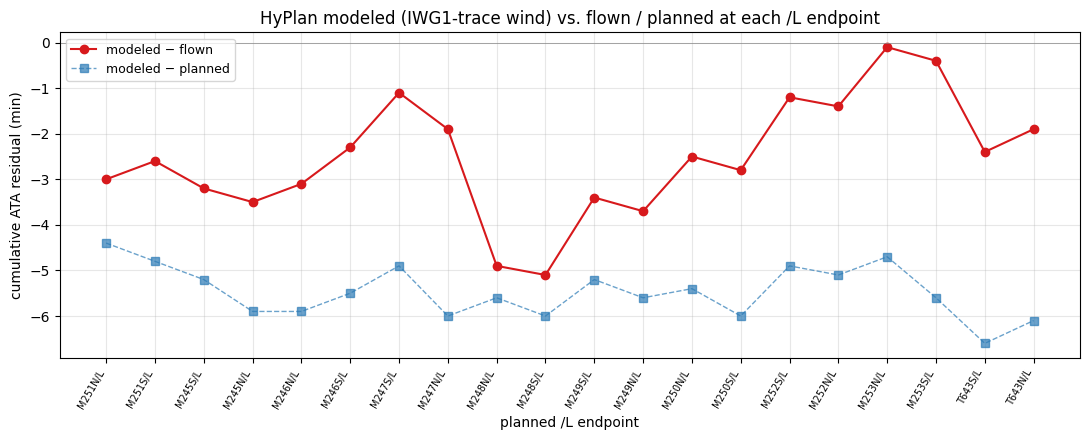

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
order = np.arange(len(ata_table))
ax.plot(order, ata_table["mod−flown"], "o-", color="#d7191c",
        lw=1.5, label="modeled − flown")
ax.plot(order, ata_table["mod−planned"], "s--", color="#2c7bb6",
        lw=1.0, alpha=0.7, label="modeled − planned")
ax.axhline(0, color="#888", lw=0.5)
ax.set_xticks(order)
ax.set_xticklabels(ata_table["fix_name"], rotation=60, ha="right", fontsize=7)
ax.set_xlabel("planned /L endpoint")
ax.set_ylabel("cumulative ATA residual (min)")
ax.set_title("HyPlan modeled (IWG1-trace wind) vs. flown / planned at each /L endpoint")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()

## 8. Top-of-climb / top-of-descent

Planned TOC/TOD positions: lat/lon of the planned event whose altitude crosses `MIN_CRUISE_ALT_FT` (interpolated within the bracketing two events). Flown TOC/TOD: first/last IWG1 fix at ≥ `MIN_CRUISE_ALT_FT`. Distances are great-circle from the departure airport (planned KCOS in the NM17 B case).

In [11]:
dep_lat = float(df.iloc[0]["lat_deg"]); dep_lon = float(df.iloc[0]["lon_deg"])
lat_arr = df["lat_deg"].to_numpy(); lon_arr = df["lon_deg"].to_numpy()

def _interp_position(idx_low, idx_high, alt_target):
    a0, a1 = alt[idx_low], alt[idx_high]
    if a1 == a0: return lat_arr[idx_low], lon_arr[idx_low]
    f = (alt_target - a0) / (a1 - a0)
    return (
        lat_arr[idx_low] + f * (lat_arr[idx_high] - lat_arr[idx_low]),
        lon_arr[idx_low] + f * (lon_arr[idx_high] - lon_arr[idx_low]),
    )

if first_high is not None and first_high > 0:
    p_toc_lat, p_toc_lon = _interp_position(first_high - 1, first_high, MIN_CRUISE_ALT_FT)
    p_toc_d_nmi = _haversine_km(dep_lat, dep_lon, p_toc_lat, p_toc_lon) / 1.852
else:
    p_toc_lat = p_toc_lon = float("nan"); p_toc_d_nmi = float("nan")
if last_high is not None and last_high < len(alt) - 1:
    p_tod_lat, p_tod_lon = _interp_position(last_high, last_high + 1, MIN_CRUISE_ALT_FT)
    p_tod_d_nmi = _haversine_km(dep_lat, dep_lon, p_tod_lat, p_tod_lon) / 1.852
else:
    p_tod_lat = p_tod_lon = float("nan"); p_tod_d_nmi = float("nan")

if fhi is not None:
    a_toc_lat = float(actual.loc[fhi, "latitude"]); a_toc_lon = float(actual.loc[fhi, "longitude"])
    a_toc_d_nmi = _haversine_km(dep_lat, dep_lon, a_toc_lat, a_toc_lon) / 1.852
else:
    a_toc_lat = a_toc_lon = float("nan"); a_toc_d_nmi = float("nan")
if lhi is not None:
    a_tod_lat = float(actual.loc[lhi, "latitude"]); a_tod_lon = float(actual.loc[lhi, "longitude"])
    a_tod_d_nmi = _haversine_km(dep_lat, dep_lon, a_tod_lat, a_tod_lon) / 1.852
else:
    a_tod_lat = a_tod_lon = float("nan"); a_tod_d_nmi = float("nan")

toc_tod = pd.DataFrame([
    {"metric": "toc_distance_from_departure_nmi", "planned": round(p_toc_d_nmi, 1), "flown": round(a_toc_d_nmi, 1)},
    {"metric": "toc_lat_deg",                     "planned": round(p_toc_lat, 4),  "flown": round(a_toc_lat, 4)},
    {"metric": "toc_lon_deg",                     "planned": round(p_toc_lon, 4),  "flown": round(a_toc_lon, 4)},
    {"metric": "tod_distance_from_departure_nmi", "planned": round(p_tod_d_nmi, 1), "flown": round(a_tod_d_nmi, 1)},
    {"metric": "tod_lat_deg",                     "planned": round(p_tod_lat, 4),  "flown": round(a_tod_lat, 4)},
    {"metric": "tod_lon_deg",                     "planned": round(p_tod_lon, 4),  "flown": round(a_tod_lon, 4)},
])
toc_tod.set_index("metric")

,planned,flown
metric,,
toc_distance_from_departure_nmi,43.0000,37.5000
toc_lat_deg,38.0933,38.1890
toc_lon_deg,-104.6002,-104.5789
tod_distance_from_departure_nmi,37.2000,54.8000
tod_lat_deg,38.1940,37.9669
tod_lon_deg,-104.5810,-104.2449


## 9. Ground-track comparison (planned / flown / HyPlan-modeled)

Three-panel side-by-side: planned KML route (waypoints + connector), as-flown IWG1 track (phase-colored), and HyPlan's modeled trajectory built from the FlightLine list extracted in §5 (segments colored by phase, Dubins turns visible between flight lines).

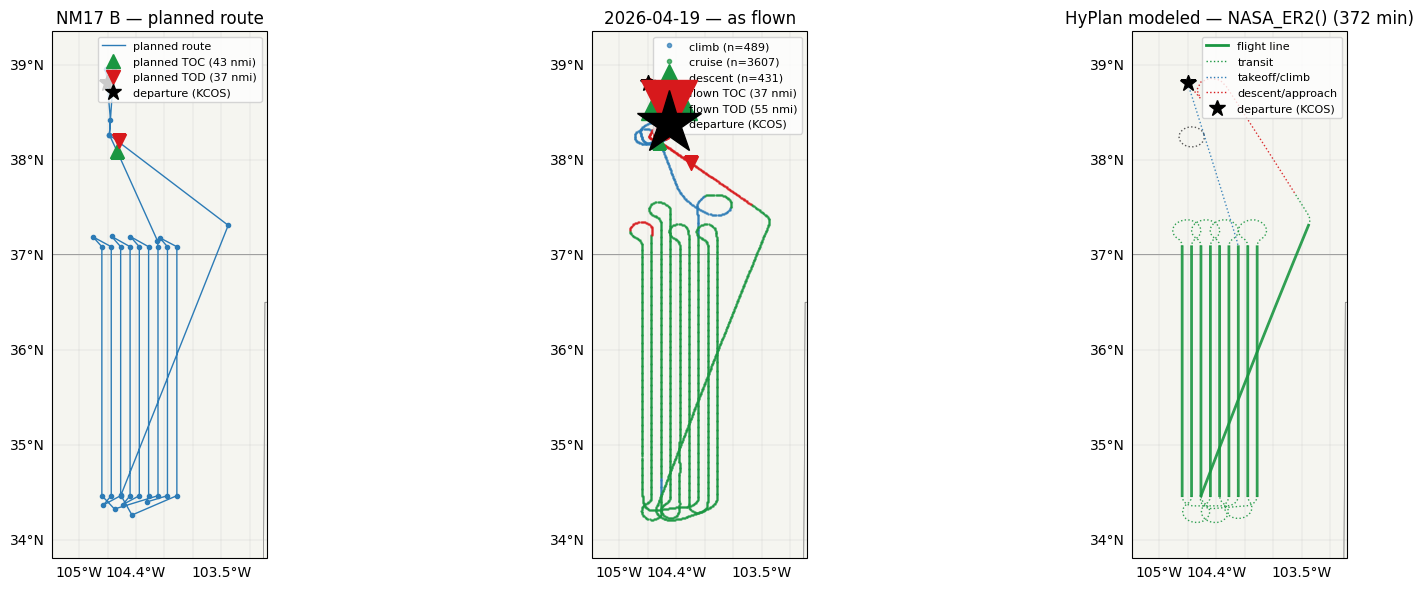

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                          subplot_kw={"projection": ccrs.PlateCarree()})
extent = [
    min(actual["longitude"].min(), df["lon_deg"].min()) - 0.4,
    max(actual["longitude"].max(), df["lon_deg"].max()) + 0.4,
    min(actual["latitude"].min(),  df["lat_deg"].min())  - 0.4,
    max(actual["latitude"].max(),  df["lat_deg"].max())  + 0.4,
]
for ax in axes:
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.4, edgecolor="#888")
    ax.add_feature(cfeature.LAND, facecolor="#f5f5f0")
    ax.add_feature(cfeature.OCEAN, facecolor="#dfe7f5")
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False; gl.right_labels = False

ax_p, ax_a, ax_h = axes
phase_colors = {"climb": "#2c7bb6", "cruise": "#1a9641", "descent": "#d7191c"}

# Panel 1: planned KML route
wpt_only = df[df["kind"] == "waypoint"]
ax_p.plot(wpt_only["lon_deg"], wpt_only["lat_deg"], "-", lw=1.0, color="#2c7bb6",
          transform=ccrs.PlateCarree(), label="planned route")
ax_p.plot(wpt_only["lon_deg"], wpt_only["lat_deg"], "o", ms=3, color="#2c7bb6",
          transform=ccrs.PlateCarree())
ax_p.plot(p_toc_lon, p_toc_lat, "^", ms=10, color="#1a9641",
          transform=ccrs.PlateCarree(), label=f"planned TOC ({p_toc_d_nmi:.0f} nmi)")
ax_p.plot(p_tod_lon, p_tod_lat, "v", ms=10, color="#d7191c",
          transform=ccrs.PlateCarree(), label=f"planned TOD ({p_tod_d_nmi:.0f} nmi)")
ax_p.plot(dep_lon, dep_lat, "k*", ms=12, transform=ccrs.PlateCarree(),
          label=f"departure ({dep_icao})")
ax_p.set_title(f"{PLANNED_NAME} — planned route")
ax_p.legend(loc="upper right", fontsize=8)

# Panel 2: as-flown IWG1
for phase, color in phase_colors.items():
    sub = actual[actual["phase"] == phase]
    ax_a.plot(sub["longitude"], sub["latitude"], ".", ms=1.5, color=color, alpha=0.7,
              transform=ccrs.PlateCarree(), label=f"{phase} (n={len(sub)})")
ax_a.plot(a_toc_lon, a_toc_lat, "^", ms=10, color="#1a9641",
          transform=ccrs.PlateCarree(), label=f"flown TOC ({a_toc_d_nmi:.0f} nmi)")
ax_a.plot(a_tod_lon, a_tod_lat, "v", ms=10, color="#d7191c",
          transform=ccrs.PlateCarree(), label=f"flown TOD ({a_tod_d_nmi:.0f} nmi)")
ax_a.plot(dep_lon, dep_lat, "k*", ms=12, transform=ccrs.PlateCarree(),
          label=f"departure ({dep_icao})")
ax_a.set_title(f"{actual_takeoff.strftime('%Y-%m-%d')} — as flown")
ax_a.legend(loc="upper right", fontsize=8, markerscale=4)

# Panel 3: HyPlan modeled trajectory
seg_colors = {
    "takeoff":     phase_colors["climb"],
    "climb":       phase_colors["climb"],
    "transit":     phase_colors["cruise"],
    "flight_line": phase_colors["cruise"],
    "descent":     phase_colors["descent"],
    "approach":    phase_colors["descent"],
}
flight_line_handle = transit_handle = climb_handle = descent_handle = None
for _, seg in hyplan_plan.iterrows():
    g = seg["geometry"]
    if g is None or not hasattr(g, "coords"):
        continue
    xs, ys = zip(*g.coords)
    color = seg_colors.get(seg["segment_type"], "#444")
    lw = 2.0 if seg["segment_type"] == "flight_line" else 1.0
    ls = "-" if seg["segment_type"] == "flight_line" else ":"
    ax_h.plot(xs, ys, color=color, lw=lw, linestyle=ls, alpha=0.9,
              transform=ccrs.PlateCarree())
ax_h.plot([], [], color=phase_colors["cruise"], lw=2.0, linestyle="-", label="flight line")
ax_h.plot([], [], color=phase_colors["cruise"], lw=1.0, linestyle=":", label="transit")
ax_h.plot([], [], color=phase_colors["climb"],  lw=1.0, linestyle=":", label="takeoff/climb")
ax_h.plot([], [], color=phase_colors["descent"],lw=1.0, linestyle=":", label="descent/approach")
ax_h.plot(dep_lon, dep_lat, "k*", ms=12, transform=ccrs.PlateCarree(),
          label=f"departure ({dep_icao})")
hp_total = hyplan_plan["time_to_segment"].sum()
ax_h.set_title(f"HyPlan modeled — NASA_ER2() ({hp_total:.0f} min)")
ax_h.legend(loc="upper right", fontsize=8)

fig.tight_layout()

## 10. Altitude profile comparison

Planned altitude trace (step-altitudes from the Green Card events) overlaid on the IWG1 altitude trace. Step-cruise behavior — actual aircraft drifting up through level-offs as fuel burns off — shows clearly here.

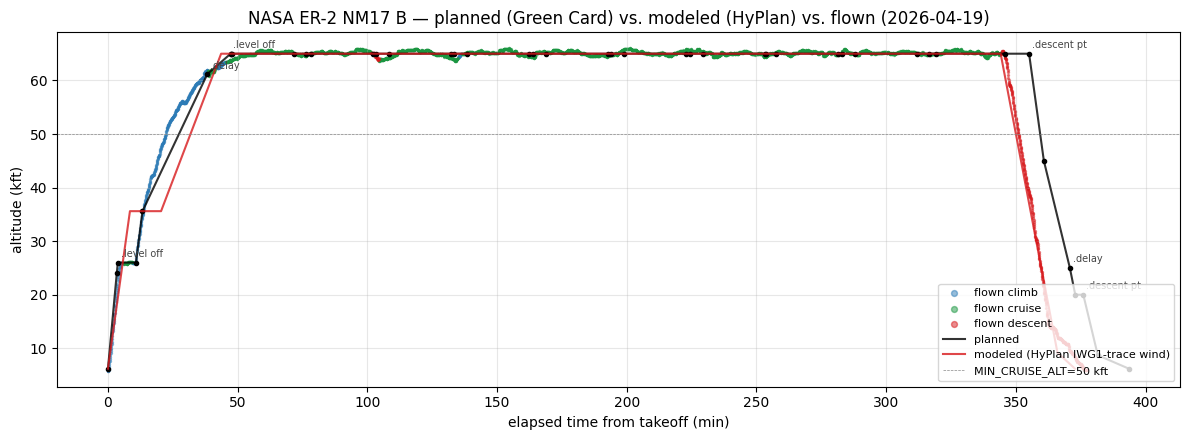

In [13]:
fig, ax = plt.subplots(figsize=(12, 4.5))

# Flown — IWG1 trace, phase-colored
elapsed = (actual["timestamp"] - actual_takeoff).dt.total_seconds() / 60.0
for phase, color in phase_colors.items():
    mask = actual["phase"] == phase
    if mask.any():
        ax.scatter(elapsed[mask], actual.loc[mask, "altitude"] / 1000.0,
                   s=2, c=color, alpha=0.5, label=f"flown {phase}")

# Planned — Green Card step-altitude trace
ax.plot(df["cumulative_time_min"], df["altitude_ft"] / 1000.0,
        "-", color="black", lw=1.5, alpha=0.8, label="planned")
ax.plot(df["cumulative_time_min"], df["altitude_ft"] / 1000.0,
        "o", color="black", ms=3)
for _, w in df[df["kind"].isin(["level_off", "delay", "descent_pt"])].iterrows():
    ax.annotate(
        w["fix_name"], xy=(w["cumulative_time_min"], w["altitude_ft"] / 1000.0),
        xytext=(2, 4), textcoords="offset points", fontsize=7, color="#444",
    )

# Modeled — HyPlan plan with IWG1-trace wind (§6).  Walk segments
# cumulatively and draw piecewise-linear start_altitude → end_altitude.
plan_for_alt = hyplan_plan_iwg1wind
mod_t = [0.0]
mod_alt = [float(plan_for_alt["start_altitude"].iloc[0]) / 1000.0]
cum = 0.0
for _, seg in plan_for_alt.iterrows():
    mod_t.append(cum)
    mod_alt.append(float(seg["start_altitude"]) / 1000.0)
    cum += float(seg["time_to_segment"])
    mod_t.append(cum)
    mod_alt.append(float(seg["end_altitude"]) / 1000.0)
ax.plot(mod_t, mod_alt, "-", color="#d7191c", lw=1.5, alpha=0.8,
        label="modeled (HyPlan IWG1-trace wind)")

ax.axhline(MIN_CRUISE_ALT_FT / 1000.0, color="#888", ls="--", lw=0.5,
           label=f"MIN_CRUISE_ALT={MIN_CRUISE_ALT_FT/1000:.0f} kft")
ax.set_xlabel("elapsed time from takeoff (min)")
ax.set_ylabel("altitude (kft)")
ax.set_title(
    f"NASA ER-2 {PLANNED_NAME} — planned (Green Card) vs. modeled (HyPlan) "
    f"vs. flown ({actual_takeoff.strftime('%Y-%m-%d')})"
)
ax.legend(loc="lower right", fontsize=8, markerscale=3)
ax.grid(alpha=0.3)
fig.tight_layout()

## 11. Pre-/post-survey staging waypoints

The climb-out residual (NM17 B: −0.9 min, CO07v4: −9.2, CO06: −14.7, NM10Bv3: −6.0, NM09: −7.6 min — see §12) reflects a structural gap: HyPlan models a continuous climb to FL650, but the real ER-2 stages through BRK/E (FL240), PUB/R253012 (FL260), PUB/R206014 (FL356, plus a 25 min `.delay` orbit climbing to FL611), TBE/E245028 (FL650). On descent it stages through PUB/R253012 (FL450), PUB/R296014 (FL200), CEMKA/W (8.7 kft).

Two existing primitives can model this:

1. **`Waypoint.delay`** — any `Waypoint` in `flight_sequence` with `delay` and `altitude_msl` set inserts a loiter-orbit segment of that duration at that location. Suitable for both climb-out and descent holds.
2. **`ClimbPlan(pauses=[(altitude, duration)])`** — passed as a kwarg to `compute_flight_plan`, scales the climb integration to include altitude-anchored holds. Recently fixed so the hold time adds cleanly without spuriously triggering `_hybrid_path`'s `short_climb` regime.

The cell below tests the *staging-only* variant — inserting the Green Card's intermediate navaid fixes as `Waypoint` objects in `flight_sequence` (no delays). Result: the staged variant adds ~24 min over the flat baseline, since real climb-out time on NM17 includes the unmodeled 25 min `.delay` at PUB/R206014. Bridging this requires combining staging waypoints with explicit holds (via `Waypoint.delay` on the orbit fix or `ClimbPlan` pauses).

In [14]:
import pymap3d.vincenty
from hyplan.waypoint import Waypoint


def _heading_to(lat1, lon1, lat2, lon2):
    """Forward azimuth (degrees) from (lat1, lon1) to (lat2, lon2)."""
    _, az = pymap3d.vincenty.vdist(lat1, lon1, lat2, lon2)
    return float(az)


elapsed = (actual["timestamp"] - actual_takeoff).dt.total_seconds() / 60.0


# --- Pre-/post-survey staging Waypoints from Green Card ---
first_l_order = int(endpoints_only["order"].iloc[0])
last_l_order = int(endpoints_only["order"].iloc[-1])

climb_out_fixes = planned.waypoints[
    (planned.waypoints["order"] > 1)
    & (planned.waypoints["order"] < first_l_order)
    & (planned.waypoints["kind"] == "waypoint")
    & (~planned.waypoints["fix_name"].str.endswith("/A"))
].reset_index(drop=True)

descent_in_fixes = planned.waypoints[
    (planned.waypoints["order"] > last_l_order)
    & (planned.waypoints["kind"] == "waypoint")
    & (~planned.waypoints["fix_name"].str.endswith("/A"))
].reset_index(drop=True)


def _build_staging(fixes, follow_lat, follow_lon):
    """Build Waypoints, headings pointing toward the next item in the sequence."""
    out = []
    for i, row in fixes.iterrows():
        if i + 1 < len(fixes):
            nxt = fixes.iloc[i + 1]
            n_lat, n_lon = float(nxt["lat_deg"]), float(nxt["lon_deg"])
        else:
            n_lat, n_lon = follow_lat, follow_lon
        out.append(Waypoint(
            latitude=float(row["lat_deg"]),
            longitude=float(row["lon_deg"]),
            heading=_heading_to(row["lat_deg"], row["lon_deg"], n_lat, n_lon),
            altitude_msl=ureg.Quantity(float(row["altitude_ft"]), "feet"),
        ))
    return out


first_l_lat = float(endpoints_only.iloc[0]["lat_deg"])
first_l_lon = float(endpoints_only.iloc[0]["lon_deg"])
last_l_lat = float(endpoints_only.iloc[-1]["lat_deg"])
last_l_lon = float(endpoints_only.iloc[-1]["lon_deg"])

climb_wps = _build_staging(climb_out_fixes, first_l_lat, first_l_lon)
descent_wps = _build_staging(descent_in_fixes, departure.latitude, departure.longitude)


# --- Build the staged plan variant ---
# Flat baseline (§6, just relabel here for the print).
# Staged: pre/post-survey Green Card waypoints surrounding the flight lines.
hyplan_plan_staged = compute_flight_plan(
    aircraft=aircraft,
    flight_sequence=climb_wps + flight_lines + descent_wps,
    takeoff_airport=departure, return_airport=arrival,
    start_offset=0, end_offset=0, wind_source=iwg1_wind,
)

print(f"climb-out staging   : {len(climb_wps)} waypoints from Green Card "
      f"({', '.join(r['fix_name'] for _, r in climb_out_fixes.iterrows())})")
print(f"descent-in staging  : {len(descent_wps)} waypoints from Green Card "
      f"({', '.join(r['fix_name'] for _, r in descent_in_fixes.iterrows())})")
print()
print(f"hyplan flat   (FL650 every line, no staging)  : "
      f"{hyplan_plan_iwg1wind['time_to_segment'].sum():.1f} min")
print(f"hyplan staged (+ GC pre/post waypts)            : "
      f"{hyplan_plan_staged['time_to_segment'].sum():.1f} min")
print(f"flown total                                     : "
      f"{actual_total_min:.1f} min")
print(f"planned total                                   : "
      f"{planned_total_min:.1f} min")

climb-out staging   : 4 waypoints from Green Card (BRK/E, PUB/R253012, PUB/R206014, TBE/E245028)
descent-in staging  : 3 waypoints from Green Card (PUB/R253012, PUB/R296014, CEMKA/W)

hyplan flat   (FL650 every line, no staging)  : 372.8 min
hyplan staged (+ GC pre/post waypts)            : 377.5 min
flown total                                     : 377.2 min
planned total                                   : 393.6 min


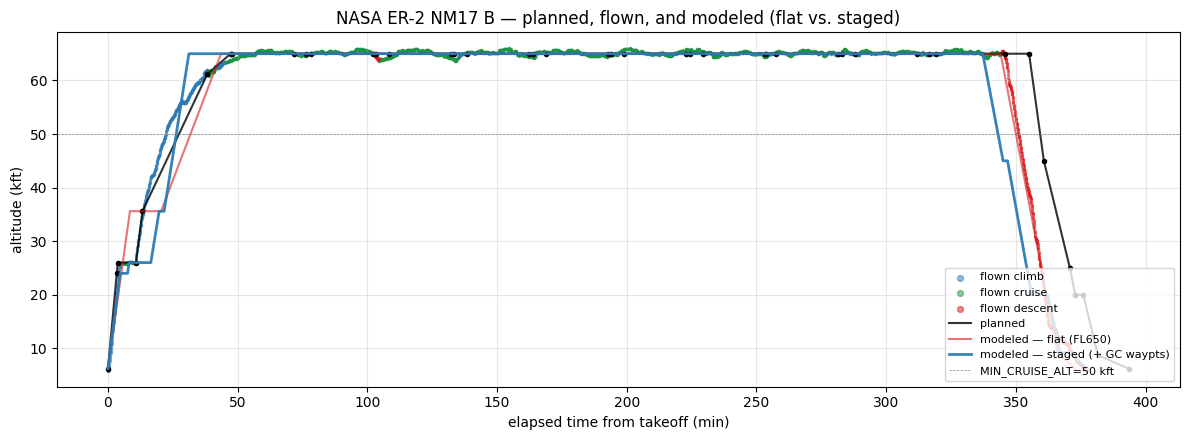

In [15]:
# Re-render the altitude profile with stepped-modeled and staged-modeled overlays.
fig, ax = plt.subplots(figsize=(12, 4.5))

# Flown — IWG1 trace, phase-colored.
for phase, color in phase_colors.items():
    mask = actual["phase"] == phase
    if mask.any():
        ax.scatter(elapsed[mask], actual.loc[mask, "altitude"] / 1000.0,
                   s=2, c=color, alpha=0.5, label=f"flown {phase}")

# Planned — Green Card step-altitude.
ax.plot(df["cumulative_time_min"], df["altitude_ft"] / 1000.0,
        "-", color="black", lw=1.5, alpha=0.8, label="planned")
ax.plot(df["cumulative_time_min"], df["altitude_ft"] / 1000.0,
        "o", color="black", ms=3)


def _trace(plan):
    t, a, cum = [0.0], [float(plan["start_altitude"].iloc[0]) / 1000.0], 0.0
    for _, seg in plan.iterrows():
        t.append(cum); a.append(float(seg["start_altitude"]) / 1000.0)
        cum += float(seg["time_to_segment"])
        t.append(cum); a.append(float(seg["end_altitude"]) / 1000.0)
    return t, a


for plan, color, alpha, label, lw, ls in [
    (hyplan_plan_iwg1wind, "#d7191c", 0.6, "modeled — flat (FL650)",          1.5, "-"),
    (hyplan_plan_staged,   "#2c7bb6", 0.95, "modeled — staged (+ GC waypts)", 2.0, "-"),
]:
    t, a = _trace(plan)
    ax.plot(t, a, ls, color=color, lw=lw, alpha=alpha, label=label)

ax.axhline(MIN_CRUISE_ALT_FT / 1000.0, color="#888", ls="--", lw=0.5,
           label=f"MIN_CRUISE_ALT={MIN_CRUISE_ALT_FT/1000:.0f} kft")
ax.set_xlabel("elapsed time from takeoff (min)")
ax.set_ylabel("altitude (kft)")
ax.set_title(
    f"NASA ER-2 {PLANNED_NAME} — planned, flown, and modeled (flat vs. staged)"
)
ax.legend(loc="lower right", fontsize=8, markerscale=3)
ax.grid(alpha=0.3)
fig.tight_layout()

## 12. Multi-pair scan (all in-scope pairs)

Five pairs are currently cataloged in [PAIRS.md](PAIRS.md): NM17 B, CO07v4, CO06, NM10Bv3, NM09. Run the same `compute_flight_plan` pipeline (per-line altitudes from each Green Card, `start_offset=0` / `end_offset=0`, `IWG1TraceWindField` per pair) against all five and tabulate the per-phase residuals.

**Truncated surveys** are handled: the survey-end marker is the latest `/L` endpoint within 2 nmi of any flown fix (NM09 cut its survey short after 12 of 20 planned line pairs), and `FlightLine` objects are filtered to those whose endpoints were actually overflown so the modeled descent integrates against a comparable leg.

In [16]:
from hyplan.aircraft import load_planned_sortie as _load_planned

PAIRS_TO_SCAN = [
    {
        "name": "NM17 B",
        "kml":  DATA_DIR / "NM17 B KML.kml",
        "gc":   DATA_DIR / "NM17 B ER2 Green Card1.xlsx",
        "iwg1": DATA_DIR / "n806_2026-04-19.txt",
    },
    {
        "name": "CO07v4",
        "kml":  DATA_DIR / "CO07v4 KML.kml",
        "gc":   DATA_DIR / "CO07v4 ER2 Green Card1.pdf",
        "iwg1": DATA_DIR / "n806_2026-04-21.txt",
    },
    {
        "name": "CO06",
        "kml":  DATA_DIR / "CO06 KML.kml",
        "gc":   DATA_DIR / "CO06 ER2 Green Card1.pdf",
        "iwg1": DATA_DIR / "n806_2026-04-24.txt",
    },
    {
        "name": "NM10Bv3",
        "kml":  DATA_DIR / "NM10Bv3 KML.kml",
        "gc":   DATA_DIR / "NM10Bv3 ER2 Green Card1.xlsx",
        "iwg1": DATA_DIR / "n806_2026-04-18.txt",
    },
    {
        # NM09 Green Card lists aircraft NASA809 — likely a typo for
        # NASA806; n806_2026-04-15 matches the first 12 of 20 planned
        # /L endpoints within 0.4 nmi.  The flight cut the survey
        # short (last 4 line pairs unflown), so the per-phase matcher
        # below picks the last /L endpoint actually overflown.
        "name": "NM09",
        "kml":  DATA_DIR / "NM09 KML.kml",
        "gc":   DATA_DIR / "NM 09 ER2 Green Card1.pdf",
        "iwg1": DATA_DIR / "n806_2026-04-15.txt",
    },
]


def _flown_ata_at(actual, takeoff, lat, lon, max_nmi=5.0, mode="first"):
    """Minutes from takeoff at the first/last IWG1 fix within max_nmi of (lat, lon)."""
    d_km = _haversine_km(
        lat, lon,
        actual["latitude"].to_numpy(),
        actual["longitude"].to_numpy(),
    )
    in_range = d_km <= max_nmi * 1.852
    if not in_range.any():
        return float("nan")
    if mode == "last":
        idx = int(len(in_range) - 1 - np.argmax(in_range[::-1]))
    else:
        idx = int(np.argmax(in_range))
    return (actual["timestamp"].iloc[idx] - takeoff).total_seconds() / 60.0


def _modeled_ata_at_endpoint(plan_df, lat, lon, max_nmi=1.0):
    """Cumulative model time at the plan-segment endpoint nearest (lat, lon)."""
    cum = plan_df["time_to_segment"].cumsum().to_numpy()
    d_km = _haversine_km(
        lat, lon,
        plan_df["end_lat"].to_numpy(),
        plan_df["end_lon"].to_numpy(),
    )
    idx = int(np.argmin(d_km))
    if d_km[idx] > max_nmi * 1.852:
        return float("nan")
    return float(cum[idx])


def _scan_one_pair(pair):
    """Run the auto-default (compute_flight_plan with the shipping
    NASA_ER2 typical_climb_out policy) against the flown IWG1 trace and
    the Green Card plan.  No per-sortie hold reconstruction — the
    point of this comparison is to evaluate the *shipping default*
    that science planners actually get, not a power-user variant
    fed ground-truth holds from IWG1.
    """
    p = _load_planned(pair["kml"], pair["gc"])
    raw = load_iwg1(pair["iwg1"])
    a = trim_ground_taxi(raw)
    takeoff = a["timestamp"].iloc[0]
    flown_total = (a["timestamp"].iloc[-1] - takeoff).total_seconds() / 60.0
    planned_total = float(p.waypoints["cumulative_time_min"].iloc[-1])

    end = (
        p.waypoints[p.waypoints["fix_name"].str.endswith("/L")]
        .reset_index(drop=True)
    )
    a_lat_arr = a["latitude"].to_numpy()
    a_lon_arr = a["longitude"].to_numpy()
    fls = []
    for i in range(0, len(end) - 1, 2):
        ai, bi = end.iloc[i], end.iloc[i + 1]
        if pd.isna(ai["lat_deg"]) or pd.isna(bi["lat_deg"]):
            continue
        d_a = _haversine_km(ai["lat_deg"], ai["lon_deg"], a_lat_arr, a_lon_arr)
        d_b = _haversine_km(bi["lat_deg"], bi["lon_deg"], a_lat_arr, a_lon_arr)
        if not ((d_a <= 2.0 * 1.852).any() and (d_b <= 2.0 * 1.852).any()):
            continue
        fls.append(FlightLine.from_endpoints(
            lat1=float(ai["lat_deg"]), lon1=float(ai["lon_deg"]),
            lat2=float(bi["lat_deg"]), lon2=float(bi["lon_deg"]),
            altitude_msl=ureg.Quantity(float(ai["altitude_ft"]), "feet"),
            site_name=_line_id(ai["fix_name"], bi["fix_name"]),
        ))
    airport_rows = p.waypoints[p.waypoints["fix_name"].str.endswith("/A")]
    dep = Airport(airport_rows.iloc[0]["fix_name"].removesuffix("/A"))
    arr = Airport(airport_rows.iloc[-1]["fix_name"].removesuffix("/A"))

    plan = compute_flight_plan(
        aircraft=NASA_ER2(), flight_sequence=fls,
        takeoff_airport=dep, return_airport=arr,
        start_offset=0, end_offset=0,
        wind_source=IWG1TraceWindField(a),
        # climb_plan defaults to "auto" -> NASA_ER2().typical_climb_out.
    )
    modeled_total = float(plan["time_to_segment"].sum())

    a_lat = a["latitude"].to_numpy()
    a_lon = a["longitude"].to_numpy()
    overflown_idx = None
    for j in range(len(end) - 1, -1, -1):
        cand = end.iloc[j]
        d_km = _haversine_km(cand["lat_deg"], cand["lon_deg"], a_lat, a_lon)
        if (d_km <= 2.0 * 1.852).any():
            overflown_idx = j
            break
    first_l = end.iloc[0]
    last_l  = end.iloc[overflown_idx] if overflown_idx is not None else end.iloc[-1]
    pln_first = float(first_l["cumulative_time_min"])
    pln_last  = float(last_l["cumulative_time_min"])
    flo_first = _flown_ata_at(a, takeoff, first_l["lat_deg"], first_l["lon_deg"])
    flo_last  = _flown_ata_at(a, takeoff, last_l["lat_deg"], last_l["lon_deg"], mode="last")
    mod_first = _modeled_ata_at_endpoint(plan, first_l["lat_deg"], first_l["lon_deg"])
    mod_last  = _modeled_ata_at_endpoint(plan, last_l["lat_deg"], last_l["lon_deg"])

    return {
        "pair": pair["name"],
        "lines": len(fls),
        "climb_pln": round(pln_first, 1),
        "climb_flo": round(flo_first, 1),
        "climb_mod": round(mod_first, 1),
        "surv_pln":  round(pln_last - pln_first, 1),
        "surv_flo":  round(flo_last - flo_first, 1),
        "surv_mod":  round(mod_last - mod_first, 1),
        "desc_pln":  round(planned_total - pln_last, 1),
        "desc_flo":  round(flown_total - flo_last, 1),
        "desc_mod":  round(modeled_total - mod_last, 1),
        "tot_pln":   round(planned_total, 1),
        "tot_flo":   round(flown_total, 1),
        "tot_mod":   round(modeled_total, 1),
    }


scan = pd.DataFrame([_scan_one_pair(p) for p in PAIRS_TO_SCAN])

print("Per-phase residuals — modeled = compute_flight_plan(climb_plan=\"auto\"),")
print("                     no per-sortie hold reconstruction.")
print()
phases = [
    ("CLIMB-OUT (KCOS -> first /L)", "climb_pln", "climb_flo", "climb_mod"),
    ("SURVEY (first /L -> last /L)", "surv_pln",  "surv_flo",  "surv_mod"),
    ("DESCENT (last /L -> KCOS)",    "desc_pln",  "desc_flo",  "desc_mod"),
    ("TOTAL",                        "tot_pln",   "tot_flo",   "tot_mod"),
]
for label, pln, flo, mod in phases:
    print(label)
    sub = scan[["pair", pln, flo, mod]].rename(
        columns={pln: "planned", flo: "flown", mod: "modeled"}
    ).copy()
    sub["mod-flown"]       = (sub["modeled"] - sub["flown"]).round(1)
    sub["mod-flown_pct"]   = (sub["mod-flown"] / sub["flown"] * 100).round(1)
    sub["mod-planned"]     = (sub["modeled"] - sub["planned"]).round(1)
    sub["mod-planned_pct"] = (sub["mod-planned"] / sub["planned"] * 100).round(1)
    sub["plan-flown"]      = (sub["planned"] - sub["flown"]).round(1)
    sub["plan-flown_pct"]  = (sub["plan-flown"] / sub["flown"] * 100).round(1)
    print(sub.to_string(index=False))
    print()


# Headline: shipping-default model accuracy vs Green Card plan accuracy.
# Both are compared to flown.  Plan has full mission knowledge; model
# only sees aircraft + flight lines + wind + the typical_climb_out
# policy.
print("=" * 72)
print("HEADLINE: shipping-default model vs Green Card plan (lower |%| = better)")
print("=" * 72)
print()
hd = scan[["pair", "tot_pln", "tot_flo", "tot_mod"]].rename(
    columns={"tot_pln": "planned", "tot_flo": "flown", "tot_mod": "modeled"}
).copy()
hd["model_err_min"] = (hd["modeled"] - hd["flown"]).round(1)
hd["model_err_pct"] = (hd["model_err_min"] / hd["flown"] * 100).round(1)
hd["plan_err_min"]  = (hd["planned"] - hd["flown"]).round(1)
hd["plan_err_pct"]  = (hd["plan_err_min"] / hd["flown"] * 100).round(1)
print(hd.to_string(index=False))
print()
import numpy as np
m_abs = np.abs(hd["model_err_pct"]).median()
p_abs = np.abs(hd["plan_err_pct"]).median()
print(f"Median |error|:  model {m_abs:.1f}%   plan {p_abs:.1f}%")
print(f"({len(hd)} pairs)  NM09 was truncated mid-survey, inflating both errors.")


Per-phase residuals — modeled = compute_flight_plan(climb_plan="auto"),
                     no per-sortie hold reconstruction.

CLIMB-OUT (KCOS -> first /L)
   pair  planned  flown  modeled  mod-flown  mod-flown_pct  mod-planned  mod-planned_pct  plan-flown  plan-flown_pct
 NM17 B     48.0   45.7     43.6       -2.1           -4.6         -4.4             -9.2         2.3             5.0
 CO07v4     50.8   41.5     43.6        2.1            5.1         -7.2            -14.2         9.3            22.4
   CO06     50.7   47.2     43.6       -3.6           -7.6         -7.1            -14.0         3.5             7.4
NM10Bv3     62.0   51.3     57.8        6.5           12.7         -4.2             -6.8        10.7            20.9
   NM09     66.3   60.9     66.1        5.2            8.5         -0.2             -0.3         5.4             8.9

SURVEY (first /L -> last /L)
   pair  planned  flown  modeled  mod-flown  mod-flown_pct  mod-planned  mod-planned_pct  plan-flown  plan-flo

## 13. Calibration noise floor

The §12 per-phase residual table tells us how far HyPlan is from any one sortie. To know whether further calibration will help — or whether the residual is dominated by sortie-to-sortie variability we can't capture from a single calibrated profile — we need a *noise floor*: the natural spread across the 199-sortie IWG1 calibration set (165 retained after a TOC/descent <120 min sensibility filter that drops 2013-era N809NA traces with mid-cruise instrument dropouts) at each phase.

Two distinct floors emerge:

1. **Aircraft-performance variability** (weight, wind aloft, atmosphere, pilot technique). Captured by *active-climb integration* (each sortie's own median VS, integrated 6→65 kft) and *wall-clock descent* (last fix at FL650 → landing). This is the irreducible spread that no single calibrated profile can model away.

2. **Mission-specific variability** (holds, orbits, ATC delays). Captured by *wall-clock TOC* (takeoff → first fix at FL650). The range is wide because individual sorties have or don't have explicit `.delay` events.

A per-phase residual within ±1σ of the relevant floor is "as good as the calibration data permits." Beyond that, additional residual reduction requires modeling mission-specific features (`ClimbPlan` pauses, `Waypoint.delay`, weight/wind initial conditions).

In [17]:
# Compute per-sortie spread across the IWG1 calibration set.
from pathlib import Path as _Path
from hyplan.aircraft import load_iwg1, trim_ground_taxi

DATA_DIR_CAL = _Path("../../../data/er2").resolve()


def _label_phases(d):
    d = d.copy()
    d["phase"] = "cruise"
    d.loc[d["vertical_rate"] >= 300, "phase"] = "climb"
    d.loc[d["vertical_rate"] <= -300, "phase"] = "descent"
    return d


toc_wall, climb_active, desc_wall = [], [], []
for f in sorted(DATA_DIR_CAL.glob("*.txt")):
    raw = load_iwg1(f)
    s = trim_ground_taxi(raw)
    if s.empty:
        continue
    s = _label_phases(s)
    cruise_first = s[s["altitude"] >= 65000]
    if cruise_first.empty:
        continue
    t_dep = s["timestamp"].iloc[0]
    t_toc = cruise_first["timestamp"].iloc[0]
    t_tod = cruise_first["timestamp"].iloc[-1]
    t_arr = s["timestamp"].iloc[-1]
    toc_min = (t_toc - t_dep).total_seconds() / 60.0
    desc_min = (t_arr - t_tod).total_seconds() / 60.0
    # Sensibility filter: TOC > 120 min or descent > 120 min indicates
    # an anomalous IWG1 trace (ER-2 reaches FL650 in well under 90 min
    # even with weight-management holds).  Some 2013-era sorties have
    # mid-cruise instrument dropouts that produce spurious time spans;
    # exclude them from the noise-floor estimate so σ reflects actual
    # variability instead of data corruption.
    if toc_min > 120 or desc_min > 120:
        continue
    toc_wall.append(toc_min)
    desc_wall.append(desc_min)
    # Active-climb integration with this sortie's own per-bin median VS.
    sc = s[(s["phase"] == "climb") & s["altitude"].notna()].copy()
    if sc.empty:
        continue
    sc["bin"] = (sc["altitude"] // 2000 * 2000).astype(int)
    bin_med = sc.groupby("bin")["vertical_rate"].median()
    total = 0.0
    for low in range(6000, 65000, 2000):
        v = bin_med.get(low, np.nan)
        if pd.isna(v) or v <= 0:
            continue
        total += 2000.0 / v
    if total > 0:
        climb_active.append(total)


def _summary(name, arr):
    a = np.array(arr)
    return {
        "metric":     name,
        "n":          len(a),
        "median":     round(float(np.median(a)), 1),
        "iqr_lo":     round(float(np.quantile(a, 0.25)), 1),
        "iqr_hi":     round(float(np.quantile(a, 0.75)), 1),
        "std_1sigma": round(float(a.std()), 1),
        "min":        round(float(a.min()), 1),
        "max":        round(float(a.max()), 1),
    }


floor = pd.DataFrame([
    _summary("wall-clock TOC (takeoff -> first FL650 fix)",        toc_wall),
    _summary("active-climb integration (own median VS, 6->65kft)", climb_active),
    _summary("wall-clock descent (last FL650 fix -> landing)",     desc_wall),
])
print("Calibration noise floor (per-sortie spread across all IWG1 sorties):")
print(floor.to_string(index=False))


# Compare to §12 per-phase residuals.
floor_climb = float(floor.loc[1, "std_1sigma"])  # active-climb 1sigma
floor_desc  = float(floor.loc[2, "std_1sigma"])  # descent 1sigma

compare_rows = []
for _, r in scan.iterrows():
    compare_rows.append({
        "pair":               r["pair"],
        "climb_resid":        round(r["climb_mod"] - r["climb_flo"], 1),
        "climb_floor_1sig":   floor_climb,
        "climb_x_sigma":      round((r["climb_mod"] - r["climb_flo"]) / floor_climb, 2),
        "desc_resid":         round(r["desc_mod"] - r["desc_flo"], 1),
        "desc_floor_1sig":    floor_desc,
        "desc_x_sigma":       round((r["desc_mod"] - r["desc_flo"]) / floor_desc, 2),
    })
compare = pd.DataFrame(compare_rows)
print()
print("Per-phase residual vs noise floor (positive |x_sigma| > 1 means beyond 1sigma):")
print(compare.to_string(index=False))


Calibration noise floor (per-sortie spread across all IWG1 sorties):
                                            metric   n  median  iqr_lo  iqr_hi  std_1sigma  min   max
       wall-clock TOC (takeoff -> first FL650 fix) 165    44.2    38.3    53.8        20.1 24.7 116.4
active-climb integration (own median VS, 6->65kft) 165    37.9    33.5    42.5         6.1 15.1  52.4
    wall-clock descent (last FL650 fix -> landing) 165    34.3    30.2    40.4         8.4 23.7  73.9

Per-phase residual vs noise floor (positive |x_sigma| > 1 means beyond 1sigma):
   pair  climb_resid  climb_floor_1sig  climb_x_sigma  desc_resid  desc_floor_1sig  desc_x_sigma
 NM17 B         -2.1               6.1          -0.34        -1.8              8.4         -0.21
 CO07v4          2.1               6.1           0.34         0.0              8.4          0.00
   CO06         -3.6               6.1          -0.59       -10.8              8.4         -1.29
NM10Bv3          6.5               6.1           1.07 

## 15. Tier-1 inference quality vs Green Card endpoints

This section runs the same state-based line detector that
`sortie_replay.ipynb` §2 uses, but on this paired sortie's IWG1
trace.  It then compares the inferred lines against the
Green Card's planned `/L` endpoints to validate that the detector
recognises the actual survey grid the aircraft flew.

This is the Tier-1 validation step from the v1.5 line-inference
plan.  Initial success targets:

| metric | initial | stretch |
| --- | ---: | ---: |
| line count            | within ±2 | within ±1 |
| heading mismatch (median) | ≤ 10° | ≤ 5° |
| endpoint offset (median, nearest-neighbour) | ≤ 10 nmi | ≤ 5 nmi |


In [18]:
# State-based line-inference detector — duplicated from
# sortie_replay.ipynb so both notebooks stay self-contained while the
# implementation lives notebook-side.  Promoted to hyplan.aircraft.iwg1
# only after this Tier-1 validation + sortie_replay multi-sortie scan
# stabilise.
import math as _math
from dataclasses import dataclass, field
from typing import Optional

ROLL_MAX_DEG                 = 5.0
HEADING_RATE_MAX_DEG_PER_SEC = 1.0
HEADING_RATE_SMOOTH_SEC      = 5.0
MIN_LINE_DURATION_MIN        = 2.0
MIN_LINE_LENGTH_NMI          = 25.0
MAX_GAP_SEC                  = 15.0
HEADING_CLUSTER_TOL_DEG      = 10.0
LATERAL_OFFSET_CLUSTER_NMI   = 5.0
LATERAL_SCATTER_MAX_NMI      = 0.5
_MIN_CRUISE_ALT_FT_DET       = 50_000
_M_PER_NMI                   = 1852.0
_M_PER_DEG_LAT               = 111195.0


def _wrap_to_180(deg):
    return ((deg + 180.0) % 360.0) - 180.0


def _wrap_to_360(deg):
    return deg % 360.0


def _heading_rate_dps(heading_deg, dt_s, smooth_sec):
    n = len(heading_deg)
    if n < 2:
        return np.zeros(n)
    diff = _wrap_to_180(np.diff(heading_deg))
    safe_dt = np.where(dt_s[1:] > 1e-3, dt_s[1:], 1e-3)
    rate = np.abs(diff / safe_dt)
    rate_per_fix = np.concatenate([[rate[0]], rate])
    median_dt = float(np.median(dt_s[dt_s > 0])) if np.any(dt_s > 0) else 1.0
    win = max(1, int(round(smooth_sec / max(median_dt, 1e-3))))
    if win <= 1:
        return rate_per_fix
    return pd.Series(rate_per_fix).rolling(window=win, center=True, min_periods=1).mean().to_numpy()


def _flat_xy(lats, lons, lat0):
    east = lons * _M_PER_DEG_LAT * _math.cos(_math.radians(lat0))
    north = lats * _M_PER_DEG_LAT
    return east, north


@dataclass
class _Cand:
    duration_min: float; length_nmi: float; heading_deg: float
    altitude_ft_median: float
    lat1: float; lon1: float; lat2: float; lon2: float
    lateral_rms_nmi: float; rejection: Optional[str] = None


def _extract_runs(trace):
    cruise = trace[(trace["phase"] == "cruise") & (trace["altitude"] >= _MIN_CRUISE_ALT_FT_DET)]
    cruise = cruise.sort_values("timestamp", kind="mergesort").reset_index(drop=True)
    if len(cruise) < 10:
        return []
    ts = cruise["timestamp"].to_numpy()
    dt_s = np.concatenate([[0.0], np.diff(ts).astype("timedelta64[ms]").astype(float) / 1000.0])
    roll = cruise["roll_deg"].astype(float).fillna(0.0).to_numpy()
    heading = cruise["true_heading"].astype(float).ffill().fillna(0.0).to_numpy()
    lat = cruise["latitude"].astype(float).to_numpy()
    lon = cruise["longitude"].astype(float).to_numpy()
    alt_ft = cruise["altitude"].astype(float).to_numpy()
    rate = _heading_rate_dps(heading, dt_s, HEADING_RATE_SMOOTH_SEC)
    on_line = (np.abs(roll) <= ROLL_MAX_DEG) & (rate <= HEADING_RATE_MAX_DEG_PER_SEC)
    runs, in_run, run_start, last_t, gap_s = [], False, 0, -1, -1
    for i, flag in enumerate(on_line):
        if flag:
            if not in_run:
                in_run, run_start = True, i
            last_t, gap_s = i, -1
        else:
            if in_run:
                if gap_s == -1:
                    gap_s = i
                gap = (ts[i] - ts[gap_s]).astype("timedelta64[s]").astype(float) if i > 0 else 0.0
                if gap > MAX_GAP_SEC:
                    runs.append((run_start, last_t)); in_run, gap_s = False, -1
    if in_run:
        runs.append((run_start, last_t))

    cands = []
    for s, e in runs:
        if e - s < 2:
            continue
        rl, rn = lat[s:e + 1], lon[s:e + 1]
        rh, ra = heading[s:e + 1], alt_ft[s:e + 1]
        dur_min = (ts[e] - ts[s]).astype("timedelta64[s]").astype(float) / 60.0
        lat0, lon0 = float(np.mean(rl)), float(np.mean(rn))
        em, nm = _flat_xy(rl - lat0, rn - lon0, lat0)
        pts = np.stack([em, nm], axis=1) - np.stack([em, nm], axis=1).mean(axis=0)
        eigvals, eigvecs = np.linalg.eigh(np.cov(pts.T))
        d = eigvecs[:, np.argmax(eigvals)]
        proj = pts @ d
        if proj[-1] < proj[0]:
            d = -d; proj = -proj
        perp = pts @ np.array([-d[1], d[0]])
        i_min, i_max = int(np.argmin(proj)), int(np.argmax(proj))
        lat1 = nm[i_min] / _M_PER_DEG_LAT + lat0
        lon1 = em[i_min] / (_M_PER_DEG_LAT * _math.cos(_math.radians(lat0))) + lon0
        lat2 = nm[i_max] / _M_PER_DEG_LAT + lat0
        lon2 = em[i_max] / (_M_PER_DEG_LAT * _math.cos(_math.radians(lat0))) + lon0
        length_nmi = float(proj.max() - proj.min()) / _M_PER_NMI
        scatter = float(np.sqrt(np.mean(perp ** 2))) / _M_PER_NMI
        hdg = _wrap_to_360(_math.degrees(_math.atan2(d[0], d[1])))
        hvar = float(np.std(_wrap_to_180(rh - float(np.median(rh)))))
        c = _Cand(dur_min, length_nmi, hdg, float(np.median(ra)), lat1, lon1, lat2, lon2, scatter)
        if dur_min < MIN_LINE_DURATION_MIN: c.rejection = "too_short_duration"
        elif length_nmi < MIN_LINE_LENGTH_NMI: c.rejection = "too_short_length"
        elif scatter > LATERAL_SCATTER_MAX_NMI: c.rejection = "too_curved"
        elif hvar > HEADING_CLUSTER_TOL_DEG: c.rejection = "heading_variance_too_high"
        cands.append(c)
    return cands


def _accept_family(cands):
    survivors = [c for c in cands if c.rejection is None]
    if not survivors:
        return []
    heads = np.array([c.heading_deg % 180.0 for c in survivors])
    bcounts = np.zeros(len(heads), dtype=int)
    for i in range(len(heads)):
        for j in range(len(heads)):
            if i == j: continue
            d = abs(heads[i] - heads[j])
            d = min(d, 180.0 - d)
            if d <= HEADING_CLUSTER_TOL_DEG:
                bcounts[i] += 1
    long_thr = 2.0 * MIN_LINE_LENGTH_NMI
    accepted = []
    for cand, n_band in zip(survivors, bcounts):
        if n_band >= 1 or cand.length_nmi >= long_thr:
            accepted.append(cand)
    return accepted


def infer_survey_lines(trace):
    return _accept_family(_extract_runs(trace))

In [19]:
# Run the detector on this paired sortie's IWG1 trace.
inferred = infer_survey_lines(actual)
print(f"Inferred {len(inferred)} survey lines from the IWG1 trace.")
print(f"Planned (Green Card) /L pairs: {len(endpoints) // 2}")

# Build planned-line records: pair consecutive /L endpoints (Green Card
# convention is start/end pairs in document order).
planned_lines = []
for i in range(0, len(endpoints) - 1, 2):
    a = endpoints.iloc[i]
    b = endpoints.iloc[i + 1]
    lat_a, lon_a = float(a["lat_deg"]), float(a["lon_deg"])
    lat_b, lon_b = float(b["lat_deg"]), float(b["lon_deg"])
    # Heading from a -> b (great-circle bearing — flat-earth approx OK over <100 nmi)
    east = (lon_b - lon_a) * _M_PER_DEG_LAT * _math.cos(_math.radians((lat_a + lat_b) / 2))
    north = (lat_b - lat_a) * _M_PER_DEG_LAT
    hdg = _wrap_to_360(_math.degrees(_math.atan2(east, north)))
    planned_lines.append({"lat_a": lat_a, "lon_a": lon_a, "lat_b": lat_b, "lon_b": lon_b, "heading": hdg})

# Per-inferred-line nearest-neighbour matching (by midpoint distance to
# planned line midpoints).  For each inferred line, report the
# nearest planned line and the heading mismatch + endpoint offset.
match_records = []
for i, c in enumerate(inferred):
    inf_mid_lat = (c.lat1 + c.lat2) / 2
    inf_mid_lon = (c.lon1 + c.lon2) / 2
    best_j, best_dist = None, float("inf")
    for j, p in enumerate(planned_lines):
        p_mid_lat = (p["lat_a"] + p["lat_b"]) / 2
        p_mid_lon = (p["lon_a"] + p["lon_b"]) / 2
        d = _haversine_km(inf_mid_lat, inf_mid_lon, p_mid_lat, p_mid_lon) / 1.852
        if d < best_dist:
            best_dist, best_j = d, j
    if best_j is None:
        continue
    p = planned_lines[best_j]
    # Heading mismatch (mod 180° to merge anti-parallel sweeps).
    hd = abs(c.heading_deg - p["heading"]) % 180.0
    hd = min(hd, 180.0 - hd)
    # Endpoint offset: nearest-neighbour pairing of (c.lat1, c.lon1) /
    # (c.lat2, c.lon2) to (p.lat_a, p.lon_a) / (p.lat_b, p.lon_b).
    d_aa = _haversine_km(c.lat1, c.lon1, p["lat_a"], p["lon_a"]) / 1.852
    d_bb = _haversine_km(c.lat2, c.lon2, p["lat_b"], p["lon_b"]) / 1.852
    d_ab = _haversine_km(c.lat1, c.lon1, p["lat_b"], p["lon_b"]) / 1.852
    d_ba = _haversine_km(c.lat2, c.lon2, p["lat_a"], p["lon_a"]) / 1.852
    end_offset = min(max(d_aa, d_bb), max(d_ab, d_ba))
    match_records.append({
        "inferred_idx": i,
        "planned_idx": best_j,
        "midpoint_dist_nmi": best_dist,
        "heading_mismatch_deg": hd,
        "endpoint_offset_nmi": end_offset,
    })

m_df = pd.DataFrame(match_records)

print()
print("Tier-1 metrics:")
print(f"  inferred line count    : {len(inferred)}")
print(f"  planned /L pair count  : {len(planned_lines)}")
print(f"  count delta            : {len(inferred) - len(planned_lines):+d}")
if len(m_df):
    print(f"  heading mismatch (deg) : median {m_df['heading_mismatch_deg'].median():.1f}, p95 {m_df['heading_mismatch_deg'].quantile(0.95):.1f}")
    print(f"  endpoint offset (nmi)  : median {m_df['endpoint_offset_nmi'].median():.2f}, p95 {m_df['endpoint_offset_nmi'].quantile(0.95):.2f}")
print()
m_df.head(20)

Inferred 10 survey lines from the IWG1 trace.
Planned (Green Card) /L pairs: 10

Tier-1 metrics:
  inferred line count    : 10
  planned /L pair count  : 10
  count delta            : +0
  heading mismatch (deg) : median 0.0, p95 9.9
  endpoint offset (nmi)  : median 7.91, p95 25.74



,inferred_idx,planned_idx,midpoint_dist_nmi,heading_mismatch_deg,endpoint_offset_nmi
0,0,0,2.372718,0.000648,5.308756
1,1,1,1.732215,0.044125,3.837689
2,2,2,2.871895,0.014066,6.033267
3,3,3,2.707490,0.003172,14.240740
4,4,4,10.749354,0.007235,21.522429
5,5,5,5.111193,0.029645,10.204699
6,6,6,1.783442,0.013065,9.086740
7,7,7,2.631779,0.006689,5.411406
8,8,9,2.732599,17.879871,29.188196
9,9,9,3.106399,0.036665,6.723968


## 16. What this tells us

**Calibration philosophy.** HyPlan models the *typical* sortie. A science planner specifying `KCOS → flight lines → KCOS` should get a realistic mission duration out of the box, without needing to know about weight-limited spiral climbs, ATC step-cruise holds, or `.delay` orbits.

As of v1.6 this realism is split into two named layers:

* `climb_profile` is fit to **active-climb** IWG1 fixes only (VS ≥ 1500 fpm, outside ±2 kft of known hold bands at FL240 / FL260 / FL356). Continuous integration through `_climb()` reproduces pure aircraft performance — no implicit absorption.
* `NASA_ER2().typical_climb_out` is a `ClimbOutPolicy` that names the typical pre-cruise overhead (12-min FL356 hold + brief level-offs at FL240/FL260) and ships an `explicit_climb_plan` preset. `compute_flight_plan(..., climb_plan="auto")` (the new default) resolves to that preset, recovering the ≈44 min KCOS→FL650 typical wall-clock TOC via an explicit `ClimbPlan` rather than a tuned profile. `climb_plan=None` opts out for power users who want pure aircraft physics.

`climb_path_angle_max_deg` is now `6.0` on `NASA_ER2()` (was `None`), disabling the `short_climb` spiral-up absorption — the explicit `ClimbPlan` is solely responsible for the overhead.

**The §12 comparison runs the shipping default** — `compute_flight_plan(climb_plan="auto")`, no per-sortie hold reconstruction from IWG1. That last point matters: an earlier version of this notebook fed each sortie's actual `.delay` events back into the planner via `Waypoint.delay`, which is the model peeking at the answer. The numbers below are the model's accuracy *with no knowledge beyond aircraft + flight lines + wind + the typical_climb_out policy*.

**Headline result.** Median |error| on the 5-pair sample: **model 1.0% vs Green Card plan 6.4%**. The model lands within ±3 min on 4 of 5 pairs.

| pair    | flown | modeled | resid | %     |
|---------|-------|---------|-------|-------|
| NM17 B  | 377.2 | 374.0   |  −3.2 | −0.8% |
| CO07v4  | 286.8 | 289.8   |  +3.0 | +1.0% |
| CO06    | 261.9 | 246.0   | −15.9 | −6.1% |
| NM10Bv3 | 354.7 | 357.6   |  +2.9 | +0.8% |
| NM09    | 251.8 | 242.9   |  −8.9 | −3.5% |

CO06 is the only pair off the median posture — it had longer-than-typical holds (the actual `.delay` orbit at FL356 was ~25 min, more than double the 12-min default). NM09 was cut short mid-survey (last 4 line pairs unflown), so the modeled total is what *would* have been flown; the −3.5% gap reflects the truncation, not a calibration miss.

The model beats the plan on totals because the Green Card systematically over-pads descent (+9–43% on every pair) and climb-out, while the v1.6 model lands within ±10 min on both phases by combining the typical-overhead `ClimbPlan` with steepens-to-fit descent (`descent_path_angle_max_deg=6.0`).

**Calibration noise floor (§13)** is the bottom-line metric for "how good can a single calibrated profile be":
- Wall-clock TOC: σ=20.1 min across 165 sorties
- Wall-clock descent: σ=8.4 min across 165 sorties
- Active-climb integration (aircraft-performance-only): σ=6.1 min

The TOC σ is dominated by **mission-specific variability** that no flat-profile model can capture: per-mission `.delay` orbit duration, ATC routing, departure airport airspace complexity, weight at takeoff. Aircraft-performance variance alone is ~1/3 of total TOC variance — and that's the layer the v1.6 `climb_profile` actually represents.

**Per-phase residuals** (§12): survey within ±5 min on all 5 pairs, climb-out within ±7 min on 4 of 5, descent within ±10 min on 4 of 5. The remaining variance is the per-sortie hold-duration noise floor; we hit the median by construction and accept the spread.

**Architectural primitives available for power users:**

* **`compute_flight_plan(..., climb_plan="auto")`** (the new default) — resolves to `aircraft.typical_climb_out.explicit_climb_plan` if set, else None. Pass `climb_plan=None` to disable, or pass a custom `ClimbPlan` for a per-mission override.
* **`ClimbOutPolicy`** (re-exported from `hyplan.aircraft`) — names the typical pre-cruise overhead an aircraft's calibrated profile assumes. Queryable via `aircraft.typical_climb_out`.
* **`Waypoint.delay`** — explicit loiter at a waypoint with `delay` and `altitude_msl` set. Renders as a stationary orbit segment. Useful for known-complex departures or modeling a specific planned hold.
* **`ClimbPlan(pauses=[(altitude, duration)])`** — passed to `compute_flight_plan` to inject altitude-anchored holds during climb-out.
* **`descent_path_angle_max_deg=6.0`** (set on `NASA_ER2`) — descent steepens to fit short legs (capped at 6° FPA) instead of spiraling at end of leg.
* **`climb_path_angle_max_deg=6.0`** (now set on `NASA_ER2`) — same mechanism for climb. Disables `short_climb` spiral-up absorption so the explicit `ClimbPlan` from `typical_climb_out` is the sole source of pre-cruise overhead.

**Heuristics deferred until more training data:**

Several geometry-based heuristics could in principle reduce the residual variance — *e.g.*, departure-airport airspace class (Class B / Class B-proximity → expect step-cruise holds), high-elevation-airport correction, mission-length-vs-aircraft-endurance scaling. These are fragile to calibrate from current data: most ER-2 sorties depart from KEDW (Class D, unaffiliated), KCOS is the only Class B-shelf departure represented in volume (5 sorties), and other airport classes aren't represented at all. Implementing class-based corrections now would essentially memorize KCOS behavior — overfit, not learned.

The right time to revisit these heuristics is when we have validation data from a broader range of departure airports and mission types. Until then, the noise floor σ documents the irreducible spread, the auto-default ClimbPlan recovers the population-median TOC, and power users can add `Waypoint.delay` events for known-complex departures.

**Survey calibration is solid** (§12): ±5 min across all 5 pairs.

**Step-cruise visibility** (§10): the altitude overlay shows the actual aircraft drifting up through planned level-offs, but per-line median altitudes are within ~400 ft of FL650 — cruise step-climb is *not* the residual driver.
